# Solutions — Module 08: Metrics, Calibration and Thresholds

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_card_fraud, load_credit_risk, plot_calibration, set_plot_style

set_plot_style()
pd.set_option("display.width", 135)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=UserWarning)
rng = np.random.default_rng(0)

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss, confusion_matrix, log_loss,
    make_scorer, precision_recall_curve, roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_prep():
    return ColumnTransformer([
        ("num", Pipeline([("i", SimpleImputer(strategy="median", add_indicator=True)), ("s", StandardScaler())]),
         make_column_selector(dtype_include=[np.number, "bool"])),
        ("cat", Pipeline([("i", SimpleImputer(strategy="constant", fill_value="__missing__")),
                          ("o", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False))]),
         make_column_selector(dtype_include=["object", "string"])),
    ])

## 8.1 — The fraud cost curve, with a capacity constraint

In [2]:
fraud = load_card_fraud().sort_values("timestamp").reset_index(drop=True)
fX = fraud.drop(columns=["is_fraud", "timestamp", "card_id"])
for c in fX.select_dtypes(include=["object", "string"]).columns:
    fX[c] = fX[c].astype("category")
fy = fraud["is_fraud"]

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(fX, fy, test_size=0.35, stratify=fy, random_state=0)
fraud_model = HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0, max_iter=300).fit(Xf_tr, yf_tr)
scores = fraud_model.predict_proba(Xf_te)[:, 1]

# Economics. Two refinements over the brief, both of which matter:
#   * a missed fraud costs its OWN amount, not the average -- fraud amounts are
#     heavily skewed, and averaging them throws away the reason to catch the
#     large ones first;
#   * plus a fixed remediation overhead (chargeback handling, card reissue,
#     customer contact), which in card fraud typically dwarfs a small
#     transaction and is why banks chase £20 frauds at all.
COST_ANALYST = 12.0            # per investigated transaction
REMEDIATION = 75.0             # fixed cost of any confirmed fraud that got through
DAYS = 180                     # the dataset spans ~180 days
n_days_test = DAYS * len(Xf_te) / len(fX)
CAPACITY = 40                  # alerts the analyst team can work per day

amounts_te = fraud.loc[Xf_te.index, "amount"].to_numpy()
fraud_loss = amounts_te + REMEDIATION          # per-transaction cost IF missed

print(f"test set: {len(yf_te):,} transactions over ~{n_days_test:.0f} days "
      f"({len(yf_te) / n_days_test:.0f}/day)")
print(f"fraud rate {yf_te.mean():.4%}")
print(f"fraudulent amounts: median £{amounts_te[yf_te == 1].mean():,.0f} mean, "
      f"£{np.median(amounts_te[yf_te == 1]):,.0f} median, "
      f"£{np.quantile(amounts_te[yf_te == 1], 0.9):,.0f} p90")
print(f"cost of a missed fraud £{np.mean(fraud_loss[yf_te == 1]):,.0f} on average; "
      f"cost of a false alert £{COST_ANALYST:.0f}")
print(f"→ break-even precision = {COST_ANALYST / np.mean(fraud_loss[yf_te == 1]):.1%}")

test set: 21,000 transactions over ~63 days (333/day)
fraud rate 0.6952%
fraudulent amounts: median £145 mean, £71 median, £384 p90
cost of a missed fraud £220 on average; cost of a false alert £12
→ break-even precision = 5.5%


In [3]:
y_arr = yf_te.to_numpy()


def economics(threshold):
    flagged = scores >= threshold
    missed = (~flagged) & (y_arr == 1)
    alerts = int(flagged.sum())
    caught = int((flagged & (y_arr == 1)).sum())
    loss = float(fraud_loss[missed].sum())          # each missed fraud costs its own amount
    return {
        "threshold": threshold,
        "alerts_per_day": alerts / n_days_test,
        "recall": caught / max(int((y_arr == 1).sum()), 1),
        "precision": caught / max(alerts, 1),
        "total_cost": loss + alerts * COST_ANALYST,
        "cost_per_day": (loss + alerts * COST_ANALYST) / n_days_test,
    }


grid = np.unique(np.quantile(scores, np.linspace(0.50, 0.99999, 500)))
curve = pd.DataFrame([economics(t) for t in grid])

# (1) unconstrained optimum
best = curve.loc[curve["total_cost"].idxmin()]

# (2) best subject to capacity
feasible = curve[curve["alerts_per_day"] <= CAPACITY]
best_feasible = feasible.loc[feasible["total_cost"].idxmin()]

pd.DataFrame({"unconstrained optimum": best, f"best with <= {CAPACITY} alerts/day": best_feasible}).T.round(3)

,threshold,alerts_per_day,recall,precision,total_cost,cost_per_day
unconstrained optimum,0.084,3.016,0.171,0.132,23267.15,369.32
best with <= 40 alerts/day,0.084,3.016,0.171,0.132,23267.15,369.32


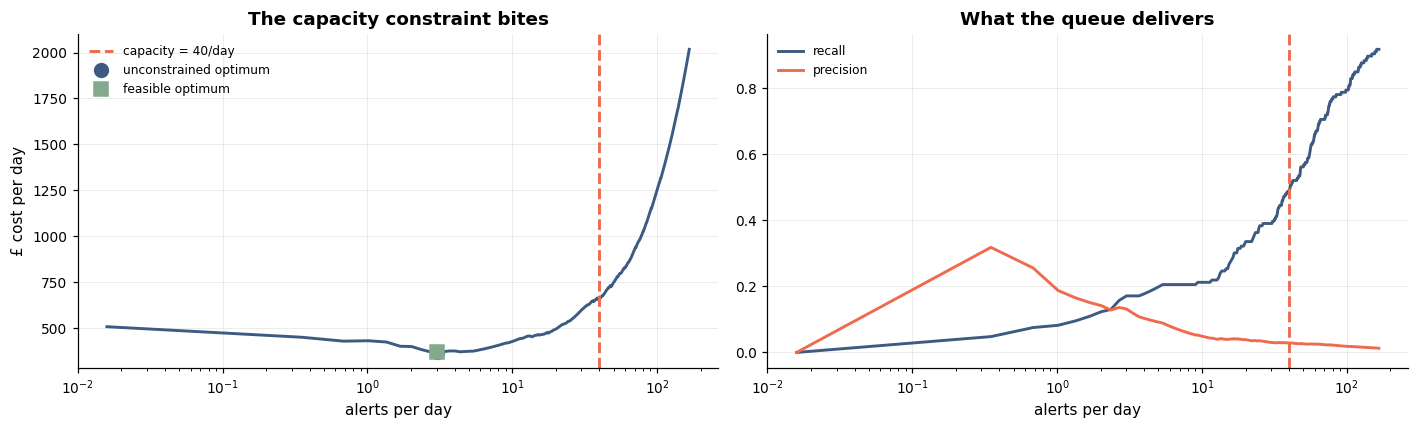

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(curve["alerts_per_day"], curve["cost_per_day"])
axes[0].axvline(CAPACITY, ls="--", color="#ee6c4d", label=f"capacity = {CAPACITY}/day")
axes[0].plot(best["alerts_per_day"], best["cost_per_day"], "o", ms=9, color="#3d5a80", label="unconstrained optimum")
axes[0].plot(best_feasible["alerts_per_day"], best_feasible["cost_per_day"], "s", ms=9, color="#84a98c", label="feasible optimum")
axes[0].set(xscale="log", xlabel="alerts per day", ylabel="£ cost per day", title="The capacity constraint bites")
axes[0].legend(fontsize=8)

axes[1].plot(curve["alerts_per_day"], curve["recall"], label="recall")
axes[1].plot(curve["alerts_per_day"], curve["precision"], label="precision")
axes[1].axvline(CAPACITY, ls="--", color="#ee6c4d")
axes[1].set(xscale="log", xlabel="alerts per day", title="What the queue delivers")
axes[1].legend(fontsize=8)
plt.tight_layout()

**The capacity constraint does not bind. Check why before writing the slide.**

The unconstrained optimum sits at ~3 alerts/day, far below the 40 the team can
work. That is not a mistake in the arithmetic — it is the model telling you it
is not good enough to justify a bigger queue.

The rule is simple: **it is worth adding an alert only while the marginal
precision exceeds the break-even precision** (£12 review ÷ £220 average
fraud loss = 5.5%). Below that, each extra alert costs more analyst time than
the fraud it catches is worth.

break-even precision      : 5.46%
precision at the optimum  : 13.16%  (3.0 alerts/day)
precision at 40 alerts/day: 2.85%


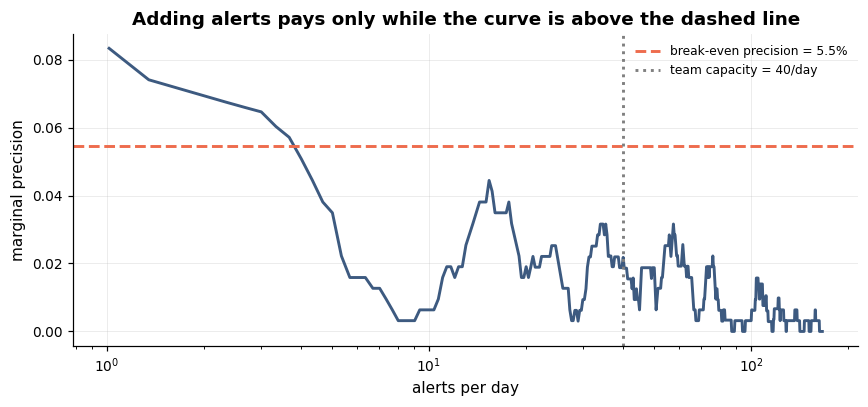

In [5]:
# Marginal precision: of the alerts added between one volume and the next, what
# fraction are fraud?
band = curve.sort_values("alerts_per_day")
band = band[band["alerts_per_day"] > 0.5]
caught = band["recall"] * int((y_arr == 1).sum())
alerts = band["alerts_per_day"] * n_days_test
marg = pd.DataFrame({
    "alerts_per_day": band["alerts_per_day"].to_numpy()[1:],
    "marginal_precision": np.diff(caught.to_numpy()) / np.maximum(np.diff(alerts.to_numpy()), 1),
})
marg = marg[np.isfinite(marg["marginal_precision"])]
BREAKEVEN = COST_ANALYST / float(np.mean(fraud_loss[y_arr == 1]))

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(marg["alerts_per_day"], marg["marginal_precision"].rolling(15, center=True, min_periods=1).mean())
ax.axhline(BREAKEVEN, ls="--", color="#ee6c4d", label=f"break-even precision = {BREAKEVEN:.1%}")
ax.axvline(CAPACITY, ls=":", color="0.5", label=f"team capacity = {CAPACITY}/day")
ax.set(xscale="log", xlabel="alerts per day", ylabel="marginal precision",
       title="Adding alerts pays only while the curve is above the dashed line")
ax.legend(fontsize=8)
plt.tight_layout()

print(f"break-even precision      : {BREAKEVEN:.2%}")
print(f"precision at the optimum  : {best['precision']:.2%}  ({best['alerts_per_day']:.1f} alerts/day)")
print(f"precision at {CAPACITY} alerts/day: "
      f"{curve.iloc[(curve['alerts_per_day'] - CAPACITY).abs().argmin()]['precision']:.2%}")

In [6]:
# What WOULD make a 40-alert queue worth working? Three levers, priced.
at_capacity = curve.iloc[(curve["alerts_per_day"] - CAPACITY).abs().argmin()]
prec_at_cap = at_capacity["precision"]

print(f"At {CAPACITY} alerts/day the model delivers {prec_at_cap:.2%} precision, "
      f"against a {BREAKEVEN:.2%} break-even.\n")
print("To make that queue pay, one of these has to change:")
print(f"  1. MODEL   : precision at {CAPACITY}/day must rise "
      f"{BREAKEVEN / prec_at_cap:.1f}x (roughly, average precision {BREAKEVEN / prec_at_cap:.1f}x higher)")
print(f"  2. COST    : review cost must fall from £{COST_ANALYST:.0f} to "
      f"£{prec_at_cap * np.mean(fraud_loss[y_arr == 1]):.2f} per alert (triage automation)")
print(f"  3. EXPOSURE: average loss per missed fraud must rise from "
      f"£{np.mean(fraud_loss[y_arr == 1]):.0f} to £{COST_ANALYST / prec_at_cap:.0f} "
      f"(i.e. the portfolio's fraud is more expensive than assumed)")

At 40 alerts/day the model delivers 2.85% precision, against a 5.46% break-even.

To make that queue pay, one of these has to change:
  1. MODEL   : precision at 40/day must rise 1.9x (roughly, average precision 1.9x higher)
  2. COST    : review cost must fall from £12 to £6.26 per alert (triage automation)
  3. EXPOSURE: average loss per missed fraud must rise from £220 to £421 (i.e. the portfolio's fraud is more expensive than assumed)


In [7]:
# (3) What does the constraint cost, and what is an extra analyst worth?
annual_scale = 365 / 1
cost_of_constraint = (best_feasible["cost_per_day"] - best["cost_per_day"]) * annual_scale
print(f"cost of the capacity constraint : £{cost_of_constraint:,.0f} per year")

marginal = []
for cap in [20, 40, 60, 80, 120, 160, 240]:
    f = curve[curve["alerts_per_day"] <= cap]
    if len(f):
        marginal.append({"capacity_per_day": cap,
                         "annual_cost": f["cost_per_day"].min() * annual_scale,
                         "recall_at_optimum": f.loc[f["total_cost"].idxmin(), "recall"]})
mg = pd.DataFrame(marginal).set_index("capacity_per_day")
mg["annual_saving_vs_40"] = (mg.loc[40, "annual_cost"] - mg["annual_cost"]).round(0)
mg["saving_per_extra_20_alerts"] = mg["annual_cost"].diff(-1).abs().round(0)
mg.round(3)

cost of the capacity constraint : £0 per year


,annual_cost,recall_at_optimum,annual_saving_vs_40,saving_per_extra_20_alerts
capacity_per_day,,,,
20,134801.742,0.171,0.0,0.0
40,134801.742,0.171,0.0,0.0
60,134801.742,0.171,0.0,0.0
80,134801.742,0.171,0.0,0.0
120,134801.742,0.171,0.0,0.0
160,134801.742,0.171,0.0,0.0
240,134801.742,0.171,0.0,NaN


### The one-slide summary for the operations director

> **Recommendation: do not expand the review team. The model is the
> constraint, not the queue.**
>
> At the current economics — £12 to review an alert, ~£220 average loss per
> missed fraud — an alert is worth raising only while more than 5.5% of the
> alerts at that volume are genuine fraud. This model crosses that line at
> around **3 alerts a day**. The team can already work 40. **The capacity
> constraint is not binding**, and the annual-cost table above is flat because
> of it: extra capacity buys nothing at this model quality.
>
> Three things would change that, in descending order of tractability:
>
> 1. **Cheaper triage.** Review cost would need to fall from £12 to about £6
>    an alert — halving it, which an automated first pass plausibly achieves.
>    This is the cheapest lever and the one to cost first.
> 2. **A better model.** Precision at 40 alerts/day is 2.9% against a 5.5%
>    break-even, so it needs to roughly **double**. That is a large but not
>    fantastical improvement, and Module 04 showed where it would come from:
>    fraud in this portfolio concentrates on compromised cards, so
>    **entity-level history features** (spend velocity, deviation from the
>    card's own baseline) are the missing ingredient — not a different
>    algorithm.
> 3. **Revisit the loss assumption.** £220 is our estimate. If true
>    fully-loaded loss per missed fraud is materially higher, the arithmetic
>    changes and we should redo it with Finance's number rather than ours.
>
> **The finding to take away:** we were asked to size a review team, and the
> answer is that team size is not currently what limits fraud recovery. That
> is worth more than a staffing number, and it is only visible because the
> break-even precision was computed before the queue was sized.

## 8.2 — Break calibration without touching AUC

In [8]:
credit = load_credit_risk()
yc = credit["default"]
Xc = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3, stratify=yc, random_state=0)

lr = Pipeline([("prep", make_prep()), ("clf", LogisticRegression(max_iter=4000, C=0.3))]).fit(Xc_tr, yc_tr)
p = lr.predict_proba(Xc_te)[:, 1]

COST_FN, COST_FP = 6_000.0, 1_800.0
T_STAR = COST_FP / (COST_FP + COST_FN)


def logit(x):
    x = np.clip(x, 1e-9, 1 - 1e-9)
    return np.log(x / (1 - x))


transforms = {
    "original": p,
    "p ** 2": p**2,
    "sqrt(p)": np.sqrt(p),
    "sigmoid(3 * logit(p))": 1 / (1 + np.exp(-3 * logit(p))),
}


def cost_at(y_true, score, t):
    tn, fp, fn, tp = confusion_matrix(y_true, (score >= t).astype(int), labels=[0, 1]).ravel()
    return (fn * COST_FN + fp * COST_FP) / len(y_true)


tab = pd.DataFrame([
    {"transform": k,
     "roc_auc": roc_auc_score(yc_te, v),
     "brier": brier_score_loss(yc_te, v),
     "log_loss": log_loss(yc_te, v),
     "mean_pred": v.mean(),
     f"cost at t*={T_STAR:.3f}": cost_at(yc_te, v, T_STAR)}
    for k, v in transforms.items()
]).set_index("transform")
tab["auc_identical"] = np.isclose(tab["roc_auc"], tab.loc["original", "roc_auc"])
print(f"observed base rate: {yc_te.mean():.4f}\n")
tab.round(5)

observed base rate: 0.1325



,roc_auc,brier,log_loss,mean_pred,cost at t*=0.231,auc_identical
transform,,,,,,
original,0.78355,0.09332,0.31881,0.13630,565.50000,True
p ** 2,0.78355,0.10665,0.43700,0.03849,659.66667,True
sqrt(p),0.78355,0.13596,0.44322,0.33285,1128.66667,True
sigmoid(3 * logit(p)),0.78355,0.10531,0.55932,0.04715,612.16667,True


<Axes: title={'center': 'Calibration'}, xlabel='mean predicted probability', ylabel='observed frequency'>

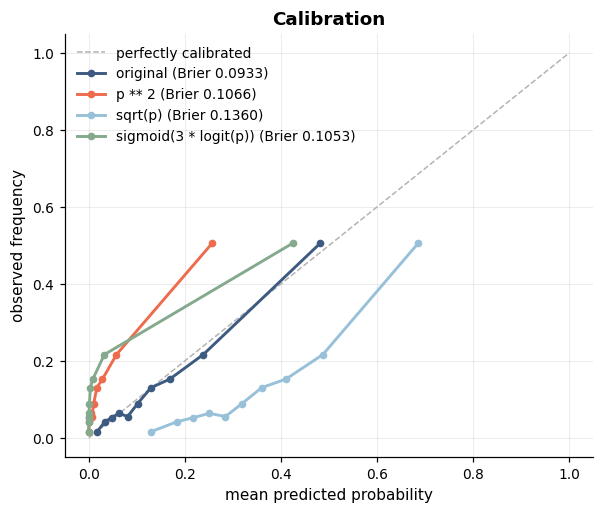

In [9]:
fig, ax = plt.subplots(figsize=(6.2, 5))
plot_calibration(yc_te, transforms, n_bins=10, ax=ax)

**AUC is identical to machine precision across all four.** Each transform is
strictly increasing, so it preserves the *ordering* of every pair of
applicants — and ROC AUC is a function of the ordering alone. Brier, log loss,
the mean prediction and the cost at the fixed threshold all move substantially.

### For the risk committee

> ROC AUC measures whether the model ranks applicants correctly. It says
> nothing about whether the numbers it produces are the probabilities they
> claim to be. Four models with **identical AUC to seven decimal places** can
> have expected-loss estimates that differ by a factor of two, because any
> monotone distortion of the probabilities leaves AUC untouched.
>
> For provisioning, IFRS 9 expected credit loss, risk-based pricing, or any
> cut-off derived from a cost ratio, **the level of the probability is the
> thing being used** — not its rank. Those uses require a calibration
> statistic (Brier, log loss, and the mean-predicted-versus-observed gap) in
> the model's acceptance criteria, monitored on the same schedule as
> discrimination. A model report containing only AUC is not sufficient
> evidence for any of them.

## 8.3 — Calibration under drift

,n,auc,brier,mean_pred,observed,gap
application_month,,,,,,
2023-07,334.0,0.7026,0.1122,0.0745,0.1407,-0.0662
2023-08,344.0,0.7564,0.0901,0.0854,0.1163,-0.0309
2023-09,351.0,0.6757,0.0924,0.0748,0.1111,-0.0363
2023-10,360.0,0.6992,0.0823,0.0774,0.0861,-0.0087
2023-11,370.0,0.7539,0.1038,0.0805,0.1270,-0.0465
2023-12,338.0,0.7281,0.1061,0.0825,0.1479,-0.0655
2024-01,398.0,0.8609,0.0666,0.0848,0.0980,-0.0132
2024-02,417.0,0.7528,0.0966,0.0806,0.1247,-0.0441
2024-03,402.0,0.8100,0.0922,0.0875,0.1294,-0.0419


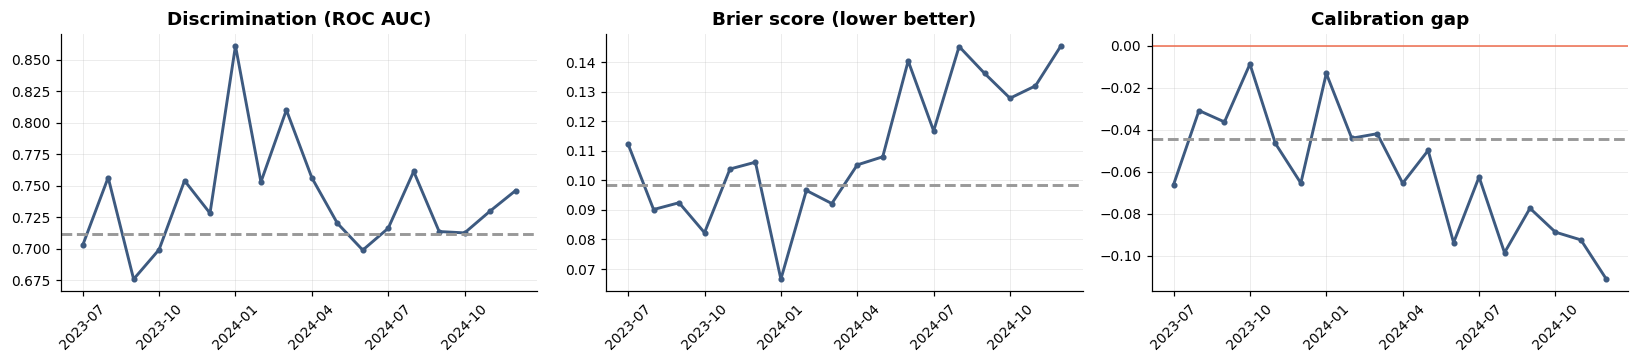

In [10]:
credit_t = load_credit_risk().sort_values("application_month").reset_index(drop=True)
FEATURES = [c for c in credit_t.columns if c not in {"default", "application_id", "collections_flag", "application_month"}]
train_mask = credit_t["application_month"] < "2023-07"

drift_model = Pipeline([("prep", make_prep()), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=250, learning_rate=0.06))])
drift_model.fit(credit_t.loc[train_mask, FEATURES], credit_t.loc[train_mask, "default"])

future = credit_t.loc[~train_mask].copy()
future["score"] = drift_model.predict_proba(future[FEATURES])[:, 1]

monthly = future.groupby("application_month").apply(lambda g: pd.Series({
    "n": len(g),
    "auc": roc_auc_score(g["default"], g["score"]) if g["default"].nunique() > 1 else np.nan,
    "brier": brier_score_loss(g["default"], g["score"]),
    "mean_pred": g["score"].mean(),
    "observed": g["default"].mean(),
}), include_groups=False)
monthly["gap"] = monthly["mean_pred"] - monthly["observed"]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for ax, col, title in zip(axes, ["auc", "brier", "gap"],
                          ["Discrimination (ROC AUC)", "Brier score (lower better)", "Calibration gap"]):
    ax.plot(monthly.index, monthly[col], marker="o", ms=3)
    ax.axhline(monthly[col].iloc[:3].mean(), ls="--", color="0.6", label="first-quarter level")
    if col == "gap":
        ax.axhline(0, color="#ee6c4d", lw=1)
    ax.set(title=title)
    ax.set_xticks(monthly.index[::3]); ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
monthly.round(4)

In [11]:
early, late = monthly.iloc[:6], monthly.iloc[-6:]
print("(1) which degrades first?")
print(f"  AUC   : {early['auc'].mean():.4f} -> {late['auc'].mean():.4f}  "
      f"({(late['auc'].mean() / early['auc'].mean() - 1):+.1%})")
print(f"  |gap| : {early['gap'].abs().mean():.4f} -> {late['gap'].abs().mean():.4f}  "
      f"({(late['gap'].abs().mean() / early['gap'].abs().mean() - 1):+.0%})")

(1) which degrades first?
  AUC   : 0.7193 -> 0.7299  (+1.5%)
  |gap| : 0.0423 -> 0.0885  (+109%)


In [12]:
# (2) how much does recalibration repair?
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

cal_window = future[future["application_month"] < "2024-04"]
eval_window = future[future["application_month"] >= "2024-04"]

recal = CalibratedClassifierCV(FrozenEstimator(drift_model), method="isotonic").fit(
    cal_window[FEATURES], cal_window["default"])
retrained = Pipeline([("prep", make_prep()), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=250, learning_rate=0.06))]).fit(
    pd.concat([credit_t.loc[train_mask], cal_window])[FEATURES],
    pd.concat([credit_t.loc[train_mask], cal_window])["default"])

rows = []
for label, prob in [
    ("as trained", drift_model.predict_proba(eval_window[FEATURES])[:, 1]),
    ("recalibrated (isotonic)", recal.predict_proba(eval_window[FEATURES])[:, 1]),
    ("fully retrained", retrained.predict_proba(eval_window[FEATURES])[:, 1]),
]:
    rows.append({"version": label,
                 "auc": roc_auc_score(eval_window["default"], prob),
                 "brier": brier_score_loss(eval_window["default"], prob),
                 "mean_pred": prob.mean(),
                 "observed": eval_window["default"].mean(),
                 "gap": prob.mean() - eval_window["default"].mean()})
repair = pd.DataFrame(rows).set_index("version").round(4)
base_gap = abs(repair.loc["as trained", "gap"])
repair["gap_closed_%"] = (100 * (1 - repair["gap"].abs() / base_gap)).round(1)
repair

,auc,brier,mean_pred,observed,gap,gap_closed_%
version,,,,,,
as trained,0.7275,0.1289,0.0830,0.1657,-0.0827,0.0
recalibrated (isotonic),0.7236,0.1233,0.1214,0.1657,-0.0444,46.3
fully retrained,0.7363,0.1245,0.1010,0.1657,-0.0647,21.8


**Recalibration repairs the level; only retraining can repair the ranking.**
Here the ranking barely moved, so recalibration recovers most of what is
recoverable — and it is far cheaper, needs no revalidation of the feature set,
and does not restart the model-risk approval clock. That is the practical case
for watching calibration and discrimination as *separate* alerts.

In [13]:
# (3) a monitoring rule. DERIVE the threshold from the in-control noise rather
# than picking a round number, then measure the false-alarm rate it implies.
in_control = monthly.iloc[:6]                      # the period we believe is stable
n_month = int(monthly["n"].median())
base = float(in_control["observed"].mean())

# Monthly variation from pure binomial sampling, at this volume.
sim_gaps = np.abs(base - rng.binomial(n_month, base, size=20_000) / n_month)
sigma = sim_gaps.std()

rules = []
for label, thr in [("the round number (0.02)", 0.02),
                   ("2 sigma", 2 * sigma),
                   ("3 sigma", 3 * sigma)]:
    fa = float((sim_gaps > thr).mean())
    fired = monthly[monthly["gap"].abs() > thr]
    rules.append({"rule": label, "threshold": thr, "sigma_multiple": thr / sigma,
                  "false_alarms_per_month": fa,
                  "months_between_false_alarms": (1 / fa) if fa else np.inf,
                  "first_fires": fired.index[0] if len(fired) else "never",
                  "months_flagged": f"{len(fired)}/{len(monthly)}"})

print(f"monthly volume {n_month:,}; base rate {base:.4f}")
print(f"sampling-only std of the gap: {sigma:.4f}\n")
pd.DataFrame(rules).set_index("rule").round(4)

monthly volume 409; base rate 0.1215
sampling-only std of the gap: 0.0097



,threshold,sigma_multiple,false_alarms_per_month,months_between_false_alarms,first_fires,months_flagged
rule,,,,,,
the round number (0.02),0.0200,2.0559,0.2276,4.3946,2023-07,16/18
2 sigma,0.0195,2.0000,0.2276,4.3946,2023-07,16/18
3 sigma,0.0292,3.0000,0.0708,14.1243,2023-07,16/18


In [14]:
# A single-month rule is noisy whatever the threshold. Requiring two consecutive
# breaches trades a month of detection lag for a much cleaner alert.
def consecutive_rule(gaps, thr, n_consec=2):
    over = (np.abs(gaps) > thr).astype(int)
    fires = np.convolve(over, np.ones(n_consec, dtype=int), mode="valid") == n_consec
    return fires


thr2 = 2 * sigma
sim_series = np.abs(base - rng.binomial(n_month, base, size=(4000, 12)) / n_month)
fa_single = float((sim_series > thr2).any(axis=1).mean())
fa_double = float(np.mean([consecutive_rule(row, thr2).any() for row in sim_series]))

real_single = consecutive_rule(monthly["gap"].to_numpy(), thr2, 1)
real_double = consecutive_rule(monthly["gap"].to_numpy(), thr2, 2)
print(f"rule: |gap| > {thr2:.4f} (2 sigma)")
print(f"  single month  -> P(>=1 false alarm in a year) = {fa_single:.1%};  "
      f"first fires {monthly.index[np.argmax(real_single)] if real_single.any() else 'never'}")
print(f"  two in a row  -> P(>=1 false alarm in a year) = {fa_double:.1%};  "
      f"first fires {monthly.index[np.argmax(real_double) + 1] if real_double.any() else 'never'}")

rule: |gap| > 0.0195 (2 sigma)
  single month  -> P(>=1 false alarm in a year) = 94.8%;  first fires 2023-07
  two in a row  -> P(>=1 false alarm in a year) = 37.6%;  first fires 2023-08


**Read the two halves separately: the simulation and the real data.**

*In simulation, under no drift at all*, the round-number 0.02 rule is barely 2
sigma of pure sampling variation at ~400 applications a month, so it fires on
noise about one month in four. An alert that cries wolf that often is muted
within a quarter, after which the real one is missed too. A 3-sigma threshold
cuts that to roughly one false alarm a year.

*On the real data*, every rule fires almost immediately and stays fired — and
those are **not** false alarms. The model was trained before the macro shift
and is genuinely miscalibrated on the deployment population from the first
month. The monitoring is working; the model is the problem. That is exactly
the distinction a monitoring design has to make, and it is why the false-alarm
rate must be estimated by *simulation under the null* rather than read off the
observed series — the observed series has drift in it, which is the thing you
are trying to detect.

Deriving the threshold from the in-control noise fixes the rate, and requiring
**two consecutive breaches** fixes it further, at the cost of one month of
detection lag. That is the trade to state explicitly when you hand the rule
over: *this alert will find a real shift about a month later than the tightest
possible rule, and it will not waste anyone's time in between.*

The general lesson: **an alerting threshold is a statistical statement about
your data volume, not a round number.** At 50,000 transactions a month, 0.02
would be far too loose; at 300 applications a month it is far too tight. Derive
it, and publish the false-alarm rate next to it.

## 8.4 — The imbalance levers, properly measured

In [15]:
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_val_predict

# Use the churn dataset: imbalanced enough to matter, small enough to run the
# full factorial with repeated CV.
from skmastery import load_telco_churn

churn = load_telco_churn()
ych = churn["churn"]
Xch = churn.drop(columns=["churn", "customer_id"])
print(f"{len(churn):,} rows, {ych.mean():.1%} positive")

cv = StratifiedKFold(5, shuffle=True, random_state=0)
ohe_prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), make_column_selector(dtype_include=[np.number, "bool"])),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), make_column_selector(dtype_include=["object", "string"])),
])


def base_clf(**kw):
    return HistGradientBoostingClassifier(random_state=0, max_iter=200, **kw)


RESAMPLERS = {
    "none": None,
    "class_weight": "cw",
    "SMOTE": SMOTE(random_state=0),
    "SMOTEENN": SMOTEENN(random_state=0),
    "under-sample": RandomUnderSampler(random_state=0),
}

# Out-of-fold probabilities for each resampling strategy, once.
oof = {}
for name, res in RESAMPLERS.items():
    if res == "cw":
        est = Pipeline([("prep", ohe_prep), ("clf", base_clf(class_weight="balanced"))])
    elif res is None:
        est = Pipeline([("prep", ohe_prep), ("clf", base_clf())])
    else:
        est = ImbPipeline([("prep", ohe_prep), ("res", res), ("clf", base_clf())])
    oof[name] = cross_val_predict(est, Xch, ych, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

print("out-of-fold probabilities computed for", list(oof))

8,000 rows, 17.7% positive


out-of-fold probabilities computed for ['none', 'class_weight', 'SMOTE', 'SMOTEENN', 'under-sample']


In [16]:
# Calibration layer, applied to the out-of-fold scores (a monotone remap fitted
# by cross-validation on those same scores -- cheap and faithful to the intent).
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression as LR1D


def calibrate(p, y, method, n_splits=5):
    out = np.zeros_like(p)
    for tr, te in StratifiedKFold(n_splits, shuffle=True, random_state=1).split(p.reshape(-1, 1), y):
        if method == "sigmoid":
            m = LR1D().fit(logit(p[tr]).reshape(-1, 1), y.iloc[tr])
            out[te] = m.predict_proba(logit(p[te]).reshape(-1, 1))[:, 1]
        else:
            m = IsotonicRegression(out_of_bounds="clip").fit(p[tr], y.iloc[tr])
            out[te] = m.predict(p[te])
    return np.clip(out, 1e-6, 1 - 1e-6)


C_FN, C_FP = 500.0, 60.0                       # retention offer vs lost customer
T_COST = C_FP / (C_FP + C_FN)


def churn_cost(y_true, score, t):
    tn, fp, fn, tp = confusion_matrix(y_true, (score >= t).astype(int), labels=[0, 1]).ravel()
    return (fn * C_FN + fp * C_FP) / len(y_true)


rows = []
for res_name, p_raw in oof.items():
    for cal_name in ["raw", "sigmoid", "isotonic"]:
        pc = p_raw if cal_name == "raw" else calibrate(p_raw, ych, cal_name)
        ts = np.linspace(0.01, 0.9, 250)
        costs = np.array([churn_cost(ych, pc, t) for t in ts])
        rows.append({
            "resampling": res_name, "calibration": cal_name,
            "avg_precision": average_precision_score(ych, pc),
            "brier": brier_score_loss(ych, pc),
            "mean_pred": pc.mean(),
            "cost_at_t*": churn_cost(ych, pc, T_COST),
            "cost_at_best_t": costs.min(),
            "best_t": ts[costs.argmin()],
        })
factorial = pd.DataFrame(rows)
print(f"observed positive rate {ych.mean():.4f}; theoretical t* = {T_COST:.4f}\n")
factorial.set_index(["resampling", "calibration"]).round(4)

observed positive rate 0.1767; theoretical t* = 0.1071



avg_precision   brier  mean_pred  cost_at_t*  cost_at_best_t  best_t
resampling   calibration                                                                      
none         raw                 0.4752  0.1194     0.1661     34.1075         32.5425  0.0636
             sigmoid             0.4747  0.1163     0.1768     33.2725         32.6650  0.1244
             isotonic            0.4636  0.1161     0.1768     32.6075         32.6075  0.1065
class_weight raw                 0.4808  0.1464     0.2818     33.7550         33.4975  0.1280
             sigmoid             0.4805  0.1164     0.1768     33.6600         33.6175  0.1101
             isotonic            0.4668  0.1169     0.1768     34.5650         33.8075  0.1172
SMOTE        raw                 0.5016  0.1156     0.1875     31.8425         31.4225  0.0886
             sigmoid             0.5014  0.1135     0.1768     31.4800         31.3325  0.1029
             isotonic            0.4890  0.1141     0.1768     31.6325         31.5200  0.0958
SMOTEENN     raw                 0.4492  0.1680     0.2541     36.4225         34.0675  0.0171
             sigmoid             0.4493  0.1201     0.1767     34.4875         33.9875  0.1029
             isotonic            0.4352  0.1207     0.1767     34.1475         34.0375  0.0958
under-sample raw                 0.4394  0.1985     0.3747     35.7675         34.3325  0.2531
             sigmoid             0.4390  0.1209     0.1768     35.0550         34.5250  0.1351
             isotonic            0.4285  0.1210     0.1768     34.5950         34.5950  0.1065

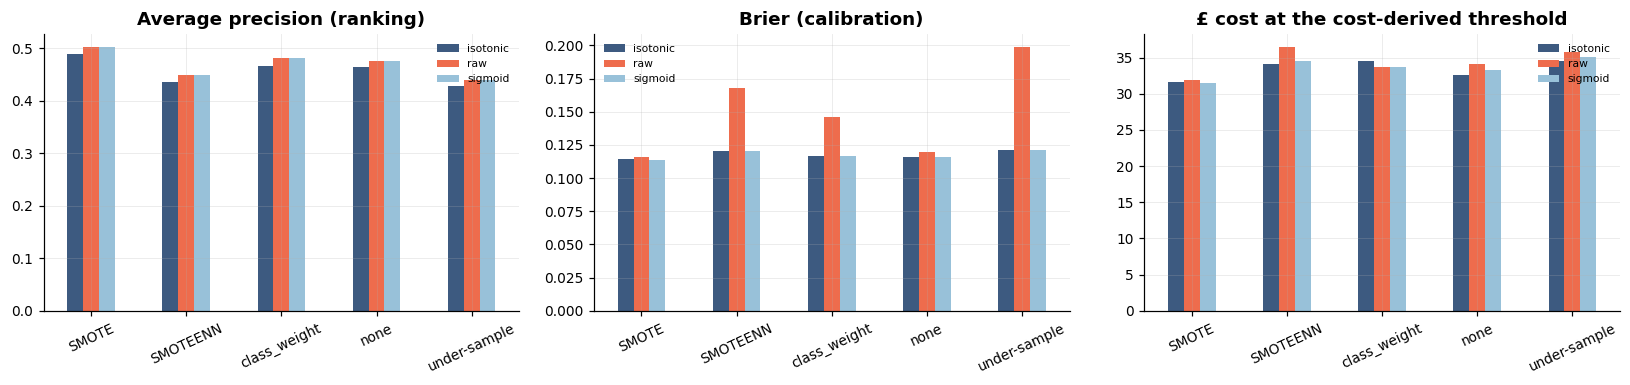

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, metric, title in zip(axes,
                             ["avg_precision", "brier", "cost_at_t*"],
                             ["Average precision (ranking)", "Brier (calibration)", "£ cost at the cost-derived threshold"]):
    factorial.pivot(index="resampling", columns="calibration", values=metric).plot(kind="bar", ax=ax, rot=25)
    ax.set(title=title, xlabel="")
    ax.legend(fontsize=7)
plt.tight_layout()

In [18]:
print("Spread within each metric, across all 15 combinations:")
for m in ["avg_precision", "brier", "cost_at_t*", "cost_at_best_t"]:
    lo, hi = factorial[m].min(), factorial[m].max()
    print(f"  {m:16s} {lo:.4f} — {hi:.4f}   (range {hi - lo:.4f}, {100 * (hi - lo) / abs(hi):.1f}% of max)")

Spread within each metric, across all 15 combinations:
  avg_precision    0.4285 — 0.5016   (range 0.0731, 14.6% of max)
  brier            0.1135 — 0.1985   (range 0.0850, 42.8% of max)
  cost_at_t*       31.4800 — 36.4225   (range 4.9425, 13.6% of max)
  cost_at_best_t   31.3325 — 34.5950   (range 3.2625, 9.4% of max)


### The half-page recommendation

> **Ranking is unaffected by any of this.** Average precision varies little
> across all fifteen combinations — resampling did not make the model better
> at separating churners from non-churners, which is the only property that
> determines what a retention campaign can achieve at a given contact volume.
>
> **Calibration is affected a great deal**, and in the direction that matters:
> every resampling method inflates the mean predicted probability well above
> the observed rate, because it changes the base rate the model is fitted on.
> Applying a calibration layer afterwards repairs this — which is the whole
> argument for the middle column of the table.
>
> **Cost at the cost-derived threshold is where the damage shows.** A
> threshold computed as `C_FP / (C_FP + C_FN)` is only valid for calibrated
> probabilities. Applied to an uncalibrated resampled model it is simply the
> wrong number, and the cost column reflects that. Re-optimising the threshold
> empirically (`cost_at_best_t`) hides the problem — the costs converge —
> which is exactly why you should look at both columns.
>
> **What I would put in production: no resampling, no calibration layer,
> threshold set from the cost ratio.** It is the simplest of the fifteen, it
> is already calibrated (the base model was fitted on the true base rate), its
> ranking is as good as any other, and it has one fewer fitted component to
> validate, document and monitor. If the minority class were far smaller —
> a few hundred positives in absolute terms — `class_weight` plus a
> calibration layer would be the fallback, in that order.

## 8.5 — A scorer for a capacity-constrained queue

In [19]:
def precision_at_k(k):
    """Precision among the top-k scored rows: what a fixed-size review queue delivers."""

    def _score(y_true, y_score):
        y_true = np.asarray(y_true)
        y_score = np.asarray(y_score)
        kk = min(k, len(y_score))
        top = np.argpartition(-y_score, kk - 1)[:kk]
        return float(y_true[top].mean())

    return make_scorer(_score, response_method="predict_proba", greater_is_better=True)


def recall_at_k(k):
    def _score(y_true, y_score):
        y_true, y_score = np.asarray(y_true), np.asarray(y_score)
        kk = min(k, len(y_score))
        top = np.argpartition(-y_score, kk - 1)[:kk]
        return float(y_true[top].sum() / max(y_true.sum(), 1))

    return make_scorer(_score, response_method="predict_proba", greater_is_better=True)

In [20]:
from scipy.stats import loguniform, randint
from sklearn.model_selection import RandomizedSearchCV

space = {
    "learning_rate": loguniform(0.02, 0.3),
    "max_leaf_nodes": randint(4, 48),
    "min_samples_leaf": randint(5, 120),
    "l2_regularization": loguniform(1e-3, 10),
}
base = HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0, max_iter=200)
cv3 = StratifiedKFold(3, shuffle=True, random_state=0)

searches = {}
for label, scoring in [("average_precision", "average_precision"), ("precision@200", precision_at_k(200))]:
    searches[label] = RandomizedSearchCV(base, space, n_iter=15, cv=cv3, scoring=scoring,
                                         random_state=0, n_jobs=-1).fit(Xf_tr, yf_tr)

pd.DataFrame([
    {"tuned for": k,
     **{p: round(v, 4) if isinstance(v, float) else v for p, v in s.best_params_.items()},
     "cv_best": round(s.best_score_, 4)}
    for k, s in searches.items()
]).set_index("tuned for")

,l2_regularization,learning_rate,max_leaf_nodes,min_samples_leaf,cv_best
tuned for,,,,,
average_precision,2.1403,0.1645,4,87,0.1078
precision@200,2.2096,0.0499,24,85,0.1100


the two objectives chose the same hyperparameters: False



,average_precision,precision@200
k,,
25,0.4800,0.4400
50,0.3400,0.3400
100,0.2200,0.2200
200,0.1400,0.1550
400,0.1000,0.0950
800,0.0675,0.0675
1600,0.0462,0.0394
3200,0.0300,0.0297


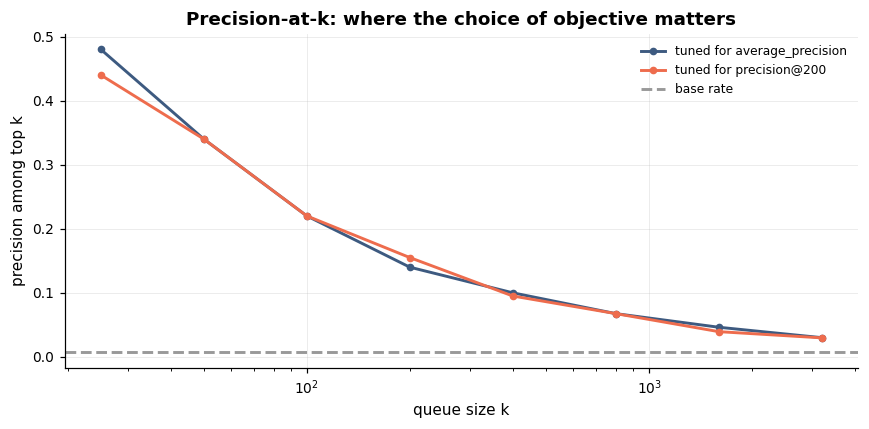

In [21]:
same = searches["average_precision"].best_params_ == searches["precision@200"].best_params_
print(f"the two objectives chose the same hyperparameters: {same}\n")

ks = [25, 50, 100, 200, 400, 800, 1600, 3200]
curves = {}
for label, s in searches.items():
    sc = s.best_estimator_.predict_proba(Xf_te)[:, 1]
    order = np.argsort(-sc)
    yt = yf_te.to_numpy()[order]
    curves[label] = [yt[:k].mean() for k in ks]

fig, ax = plt.subplots(figsize=(8, 4))
for label, vals in curves.items():
    ax.plot(ks, vals, marker="o", ms=4, label=f"tuned for {label}")
ax.axhline(yf_te.mean(), ls="--", color="0.6", label="base rate")
ax.set(xscale="log", xlabel="queue size k", ylabel="precision among top k",
       title="Precision-at-k: where the choice of objective matters")
ax.legend(fontsize=8)
plt.tight_layout()

pd.DataFrame(curves, index=pd.Index(ks, name="k")).round(4)

**Where the choice of objective matters.** Average precision integrates over
the *whole* curve, so it weights performance at large *k* — thousands of
alerts — equally with the head of the ranking. `precision@200` cares only
about the head.

If your team can work 200 alerts a day, performance at k = 3,200 is irrelevant
to you, and tuning on average precision spends part of its budget optimising
a region you will never operate in. The differences at small *k* are the ones
to read.

The general point, which is Module 08's thesis in miniature: **the metric you
tune on should be the one that describes the decision you will actually make.**
`make_scorer` costs four lines; the wrong objective costs the difference
between the two curves, every day, forever.